# 03 Synthetic CSI Generation

Generate fake CSI amplitude and phase arrays from the multipath model.

This is not hardware CSI. It is a controlled synthetic channel that lets later notebooks test processing logic before firmware exists.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
C = 299_792_458
CENTER_FREQ_HZ = 2.4e9
SUBCARRIER_SPACING_HZ = 312_500
subcarriers = np.arange(-28, 29)
subcarriers = subcarriers[subcarriers != 0]
frequencies_hz = CENTER_FREQ_HZ + subcarriers * SUBCARRIER_SPACING_HZ

tx = np.array([0.6, 2.0])
rx = np.array([4.4, 2.0])
n_samples = 500
time_s = np.linspace(0, 20, n_samples)
person = np.column_stack([
    np.linspace(1.0, 4.0, n_samples),
    1.15 + 0.7 * np.sin(2 * np.pi * time_s / time_s[-1]),
])

def distance(a, b):
    return np.linalg.norm(a - b, axis=-1)

def path_response(path_length_m, gain, frequencies_hz):
    phase = -2 * np.pi * path_length_m[..., None] * frequencies_hz[None, :] / C
    return gain[..., None] * np.exp(1j * phase)

In [2]:
direct_len = np.full(n_samples, distance(tx, rx))
person_len = distance(tx, person) + distance(person, rx)
wall_len = np.full(n_samples, 5.25)

direct_gain = np.full(n_samples, 1.0 / direct_len[0])
person_gain = 0.35 / np.maximum(person_len, 1.0)
wall_gain = np.full(n_samples, 0.12 / wall_len[0])

csi_complex = (
    path_response(direct_len, direct_gain, frequencies_hz)
    + path_response(person_len, person_gain, frequencies_hz)
    + path_response(wall_len, wall_gain, frequencies_hz)
)

csi_complex += 0.015 * (rng.normal(size=csi_complex.shape) + 1j * rng.normal(size=csi_complex.shape))
csi_amplitude = np.abs(csi_complex)
csi_phase = np.angle(csi_complex)

csi_amplitude.shape, csi_phase.shape

((500, 56), (500, 56))

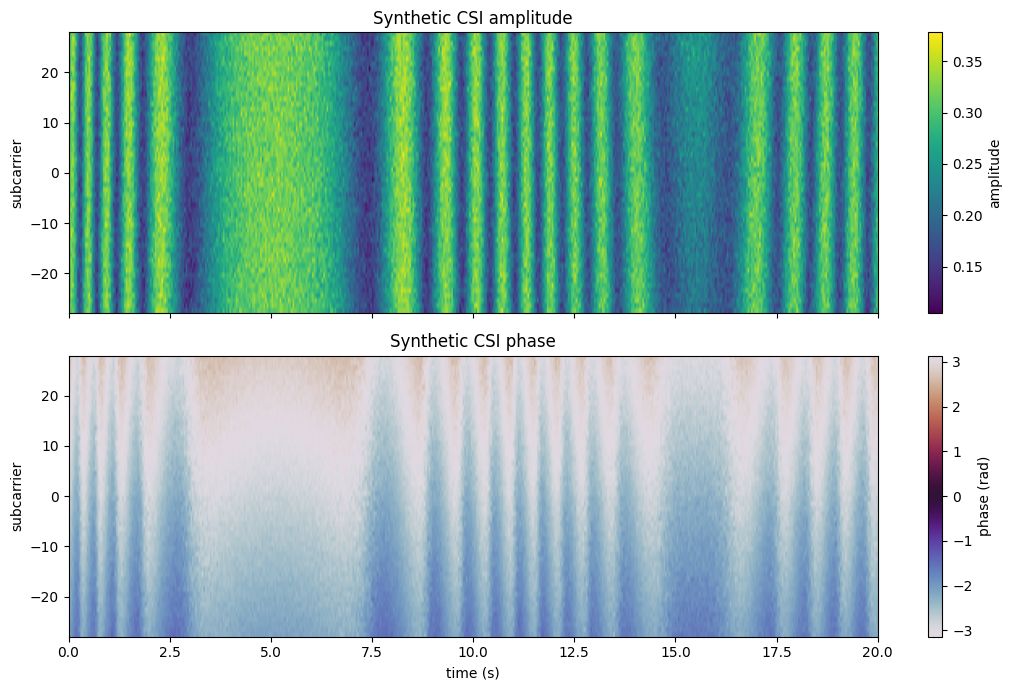

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
amp = axes[0].imshow(csi_amplitude.T, aspect="auto", origin="lower", extent=[time_s[0], time_s[-1], subcarriers[0], subcarriers[-1]], cmap="viridis")
axes[0].set_ylabel("subcarrier")
axes[0].set_title("Synthetic CSI amplitude")
fig.colorbar(amp, ax=axes[0], label="amplitude")

phase = axes[1].imshow(csi_phase.T, aspect="auto", origin="lower", extent=[time_s[0], time_s[-1], subcarriers[0], subcarriers[-1]], cmap="twilight")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("subcarrier")
axes[1].set_title("Synthetic CSI phase")
fig.colorbar(phase, ax=axes[1], label="phase (rad)")

fig.tight_layout()
plt.show()